<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/04_rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - connect Drive and Earth Engine (same project as notebook 01)
from google.colab import drive
drive.mount('/content/drive')

import ee
ee.Authenticate()
ee.Initialize(project="landslide-uttarakhand78873")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
base = "/content/drive/MyDrive/landslide_project"
print("Earth Engine ready")

Mounted at /content/drive


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine ready


In [2]:
# Cell 2 - district-average monthly rainfall from IMERG (satellite rainfall, ~11 km pixels)
aoi = (ee.FeatureCollection("FAO/GAUL/2025/level2")
       .filter(ee.Filter.eq("ISO3_CODE", "IND"))
       .filter(ee.Filter.stringContains("GAUL2_NAME", "Rudra"))
       .geometry())

imerg = ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07").select("precipitation")

# first check what's actually available - catalog pages disagree on the end date
dates = imerg.aggregate_array("system:time_start").getInfo()
print("months available:", len(dates))
print("first:", pd.to_datetime(dates[0], unit="ms").strftime("%Y-%m"),
      "| last:", pd.to_datetime(dates[-1], unit="ms").strftime("%Y-%m"))

def district_mean(img):
    # scale 5000 m so the ~11 km pixels get weighted by how much of them is inside the district
    rate = img.reduceRegion(ee.Reducer.mean(), aoi, scale=5000).get("precipitation")
    return ee.Feature(None, {"month": img.date().format("YYYY-MM"), "rate_mm_hr": rate})

feats = imerg.map(district_mean).getInfo()["features"]
rain = pd.DataFrame([f["properties"] for f in feats])
rain["month"] = pd.to_datetime(rain["month"])
# the band is an average rate in mm/hr, so monthly total = rate × hours in that month
rain["mm"] = rain["rate_mm_hr"] * rain["month"].dt.days_in_month * 24
rain["year"] = rain["month"].dt.year
rain["mon"] = rain["month"].dt.month
rain.to_csv(f"{base}/rainfall_monthly_rudraprayag.csv", index=False)

print()
print("average rainfall by calendar month (mm):")
print(rain.groupby("mon")["mm"].mean().round(0))
print()
print("June totals, highest first (2013 = Kedarnath disaster):")
print(rain[rain["mon"] == 6].sort_values("mm", ascending=False)[["year", "mm"]].head(5).round(0).to_string(index=False))

months available: 333
first: 1998-01 | last: 2025-09

average rainfall by calendar month (mm):
mon
1      77.0
2      91.0
3      92.0
4      75.0
5      95.0
6     176.0
7     477.0
8     431.0
9     253.0
10     73.0
11     19.0
12     22.0
Name: mm, dtype: float64

June totals, highest first (2013 = Kedarnath disaster):
 year    mm
 2013 501.0
 2011 360.0
 2008 358.0
 2000 343.0
 2025 287.0


complete monsoons: 28 (1998-2025)
average monsoon total: 1336 mm = 72% of the average annual total (1865 mm)

wettest monsoons:
          mm  vs_average_pct
year                        
2010  1924.0            44.0
2011  1788.0            34.0
2013  1773.0            33.0
2025  1658.0            24.0
2018  1606.0            20.0

driest monsoons:
          mm  vs_average_pct
year                        
2009   813.0           -39.0
2002   950.0           -29.0
2014  1018.0           -24.0

recent monsoons (my landslide scars were mapped in Oct-Dec 2025):
          mm  vs_average_pct
year                        
2023  1397.0             5.0
2024  1559.0            17.0
2025  1658.0            24.0


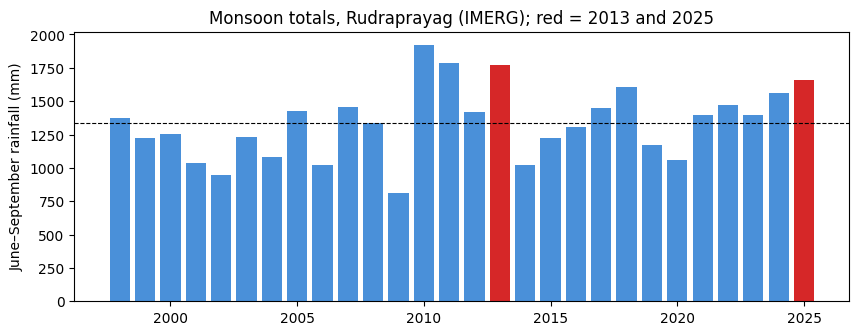

In [3]:
# Cell 3 - monsoon (June-September) total for every year
jjas = (rain[rain["mon"].between(6, 9)]
        .groupby("year").agg(mm=("mm", "sum"), months=("mm", "size")))
jjas = jjas[jjas["months"] == 4].copy()          # only years with all 4 monsoon months
clim = jjas["mm"].mean()
jjas["vs_average_pct"] = 100 * (jjas["mm"] / clim - 1)

full_years = rain.groupby("year").filter(lambda d: len(d) == 12)
annual = full_years.groupby("year")["mm"].sum().mean()
print(f"complete monsoons: {len(jjas)} ({jjas.index.min()}-{jjas.index.max()})")
print(f"average monsoon total: {clim:.0f} mm = {100 * clim / annual:.0f}% of the average annual total ({annual:.0f} mm)")
print()
print("wettest monsoons:")
print(jjas.sort_values("mm", ascending=False).head(5)[["mm", "vs_average_pct"]].round(0))
print()
print("driest monsoons:")
print(jjas.sort_values("mm").head(3)[["mm", "vs_average_pct"]].round(0))
print()
print("recent monsoons (my landslide scars were mapped in Oct-Dec 2025):")
print(jjas.loc[[y for y in [2023, 2024, 2025] if y in jjas.index], ["mm", "vs_average_pct"]].round(0))
jjas.to_csv(f"{base}/rainfall_monsoon_totals.csv")

# quick look - the proper Figure 6 comes later
colours = ["#d62728" if y in (2013, 2025) else "#4a90d9" for y in jjas.index]
plt.figure(figsize=(10, 3.5))
plt.bar(jjas.index, jjas["mm"], color=colours)
plt.axhline(clim, ls="--", c="black", lw=0.8)
plt.ylabel("June–September rainfall (mm)")
plt.title("Monsoon totals, Rudraprayag (IMERG); red = 2013 and 2025")
plt.show()

district average monsoon rainfall from the map: 1328 mm (Cell 3 said 1336 mm)
inside the district: 0 to 1663 mm per monsoon


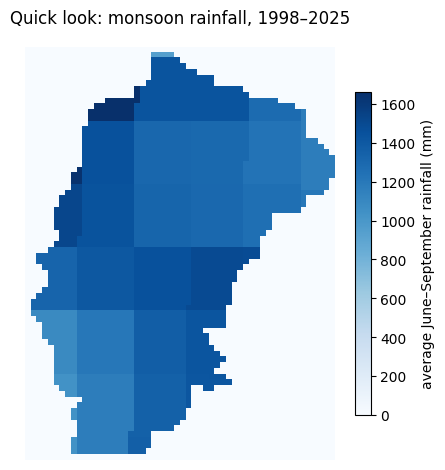

In [4]:
# Cell 4 - average monsoon (June-September) rainfall map, 1998-2025
import requests
import rasterio
from rasterio.plot import plotting_extent

def monsoon_total(year):
    year = ee.Number(year)
    months = (imerg.filter(ee.Filter.calendarRange(year, year, "year"))
                   .filter(ee.Filter.calendarRange(6, 9, "month")))
    # rate (mm/hr) × hours in that month = mm for the month
    def to_mm(img):
        hours = img.date().advance(1, "month").difference(img.date(), "hour")
        return img.multiply(hours)
    return months.map(to_mm).sum()

years = ee.List.sequence(1998, 2025)
monsoon_mean = (ee.ImageCollection(years.map(monsoon_total)).mean()
                .rename("monsoon_mm").clip(aoi))

# sanity check: the district average should match Cell 3 (~1336 mm)
check = monsoon_mean.reduceRegion(ee.Reducer.mean(), aoi, scale=5000).get("monsoon_mm").getInfo()
print(f"district average monsoon rainfall from the map: {check:.0f} mm (Cell 3 said {clim:.0f} mm)")

# download at 1 km in UTM 44N (same projection as my other maps); outside district = -9999
url = monsoon_mean.unmask(-9999).getDownloadURL({
    "region": aoi.bounds(), "scale": 1000, "crs": "EPSG:32644", "format": "GEO_TIFF"})
rain_tif = f"{base}/rudraprayag_monsoon_rain.tif"
with open(rain_tif, "wb") as f:
    f.write(requests.get(url).content)

with rasterio.open(rain_tif) as src:
    rain_map = src.read(1).astype("float32")
    rain_ext = plotting_extent(src)
rain_map[rain_map == -9999] = np.nan
print(f"inside the district: {np.nanmin(rain_map):.0f} to {np.nanmax(rain_map):.0f} mm per monsoon")

plt.figure(figsize=(5, 6))
plt.imshow(rain_map, cmap="Blues", extent=rain_ext)
plt.colorbar(label="average June–September rainfall (mm)", shrink=0.7)
plt.title("Quick look: monsoon rainfall, 1998–2025")
plt.axis("off")
plt.show()

In [5]:
# Cell 5 - rainfall vs susceptibility, and do landslides and their stable neighbours share rainfall?
import geopandas as gpd
from rasterio.warp import reproject, Resampling

# fix: outside the district came back as 0, not -9999; no real monsoon total is 0 mm
rain_map[rain_map <= 0] = np.nan
print(f"inside the district (fixed): {np.nanmin(rain_map):.0f} to {np.nanmax(rain_map):.0f} mm per monsoon")

# put the rainfall onto the 30 m susceptibility grid so the two maps line up pixel by pixel
with rasterio.open(f"{base}/rudraprayag_susceptibility.tif") as src:
    susc = src.read(1)
    s_tr, s_crs = src.transform, src.crs
with rasterio.open(rain_tif) as src:
    r_tr, r_crs = src.transform, src.crs
rain_on_susc = np.full(susc.shape, np.nan, dtype="float32")
reproject(source=rain_map, destination=rain_on_susc,
          src_transform=r_tr, src_crs=r_crs, dst_transform=s_tr, dst_crs=s_crs,
          resampling=Resampling.nearest, src_nodata=np.nan, dst_nodata=np.nan)

# same 5 classes as Figure 5 (quintiles of the modelled area)
modelled = ~np.isnan(susc)
breaks = np.quantile(susc[modelled], [0.2, 0.4, 0.6, 0.8])
cls = np.digitize(susc[modelled], breaks)
r = rain_on_susc[modelled]
ok = ~np.isnan(r)
class_names = ["Very low", "Low", "Moderate", "High", "Very high"]

stats = (pd.DataFrame({"class": np.array(class_names)[cls[ok]], "rain": r[ok]})
         .groupby("class")["rain"].agg(["mean", "median"]).reindex(class_names).round(0))
print()
print("average monsoon rainfall (mm) in each susceptibility class:")
print(stats)

wet_third = np.nanquantile(r[ok], 2 / 3)
very_high = cls[ok] == 4
share = (r[ok][very_high] >= wet_third).mean()
print(f"\n'Very high' area in the wettest third of the district: {100 * share:.0f}% (no relationship would give ~33%)")

# do landslides and their nearest stable point sit in the same rainfall pixel?
pts = gpd.read_file(f"{base}/training_points_matched.geojson").to_crs(r_crs)
with rasterio.open(rain_tif) as src:
    vals = np.array([v[0] for v in src.sample([(p.x, p.y) for p in pts.geometry])], dtype="float32")
vals[vals <= 0] = np.nan
pts["rain"] = vals
print("\naverage monsoon rainfall at the points (mm):")
print(pts.groupby("label")["rain"].mean().round(0).rename({0: "stable", 1: "landslide"}))

ls_pts = pts[pts["label"] == 1]
st_pts = pts[pts["label"] == 0]
same = [st_pts.loc[st_pts.distance(p).idxmin(), "rain"] == rv
        for p, rv in zip(ls_pts.geometry, ls_pts["rain"])]
print(f"landslides with exactly the same rainfall as their nearest stable point: "
      f"{sum(same)} of {len(same)}")

inside the district (fixed): 940 to 1663 mm per monsoon

average monsoon rainfall (mm) in each susceptibility class:
             mean  median
class                    
Very low   1368.0  1369.0
Low        1341.0  1348.0
Moderate   1329.0  1327.0
High       1326.0  1323.0
Very high  1322.0  1323.0

'Very high' area in the wettest third of the district: 33% (no relationship would give ~33%)

average monsoon rainfall at the points (mm):
label
stable       1310.0
landslide    1324.0
Name: rain, dtype: float32
landslides with exactly the same rainfall as their nearest stable point: 26 of 38


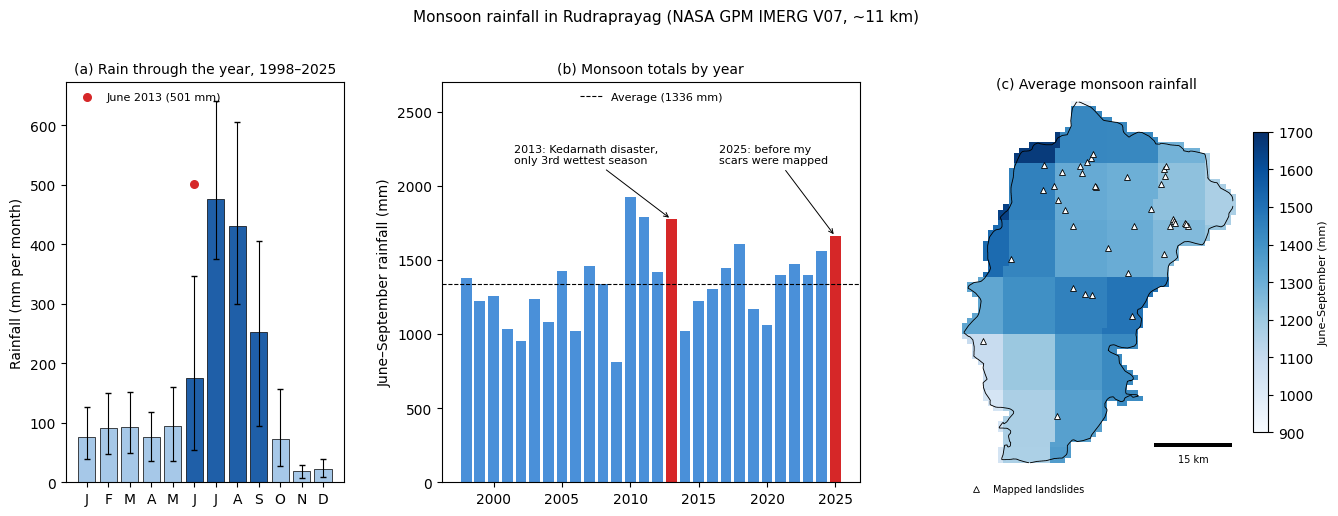

In [ ]:
# Cell 6 - Figure 6: rainfall seasonality, monsoon totals by year, spatial pattern
!pip install -q matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar

# the map needs more room, it was tiny
fig = plt.figure(figsize=(16, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.5, 1.25], wspace=0.28)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# (a) average rain for each calendar month, with the 10th-90th percentile range across years
mon = rain.groupby("mon")["mm"]
mean_m = mon.mean()
p10, p90 = mon.quantile(0.1), mon.quantile(0.9)
bar_cols = ["#1f5fa8" if m in (6, 7, 8, 9) else "#a6c8e8" for m in mean_m.index]
ax1.bar(mean_m.index, mean_m, color=bar_cols, edgecolor="black", linewidth=0.5,
        yerr=[mean_m - p10, p90 - mean_m], capsize=2, error_kw={"linewidth": 0.8})
june13 = rain.loc[(rain["year"] == 2013) & (rain["mon"] == 6), "mm"].iloc[0]
ax1.scatter([6], [june13], color="#d62728", zorder=5, s=30, label=f"June 2013 ({june13:.0f} mm)")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(list("JFMAMJJASOND"))
ax1.set_ylabel("Rainfall (mm per month)")
ax1.set_title("(a) Rain through the year, 1998–2025", fontsize=10)
ax1.legend(loc="upper left", fontsize=8, frameon=False)

# (b) monsoon totals by year
cols_b = ["#d62728" if y in (2013, 2025) else "#4a90d9" for y in jjas.index]
ax2.bar(jjas.index, jjas["mm"], color=cols_b)
ax2.axhline(clim, ls="--", c="black", lw=0.8, label=f"Average ({clim:.0f} mm)")
ax2.annotate("2013: Kedarnath disaster,\nonly 3rd wettest season", xy=(2013, jjas.loc[2013, "mm"]),
             xytext=(2001.5, 2150), fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.7))
ax2.annotate("2025: before my\nscars were mapped", xy=(2025, jjas.loc[2025, "mm"]),
             xytext=(2016.5, 2150), fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.7))
ax2.set_ylim(0, 2700)   # extra room at the top for the legend
ax2.set_ylabel("June–September rainfall (mm)")
ax2.set_title("(b) Monsoon totals by year", fontsize=10)
ax2.legend(loc="upper center", fontsize=8, frameon=False)

# (c) where the monsoon rain falls, with my landslides on top
im = ax3.imshow(rain_map, cmap="Blues", vmin=900, vmax=1700, extent=rain_ext)
with rasterio.open(f"{base}/rudraprayag_features.tif") as src:
    district = src.read(1) > 0
    d_ext = plotting_extent(src)
ax3.contour(district.astype(int), levels=[0.5], colors="black", linewidths=0.6,
            extent=d_ext, origin="upper")
ls_pts = pts[pts["label"] == 1]
ax3.scatter(ls_pts.geometry.x, ls_pts.geometry.y, marker="^", s=18, c="white",
            edgecolor="black", linewidth=0.6, zorder=5, label="Mapped landslides")
ax3.add_artist(ScaleBar(1, "m", location="lower right", length_fraction=0.3, box_alpha=0.8, font_properties={"size": 7}))
ax3.set_title("(c) Average monsoon rainfall", fontsize=10)
ax3.set_axis_off()
ax3.legend(loc="upper left", fontsize=7, frameon=False, bbox_to_anchor=(0, -0.02))
cb = fig.colorbar(im, ax=ax3, shrink=0.75)
cb.set_label("June–September (mm)", fontsize=8)

fig.suptitle("Monsoon rainfall in Rudraprayag (NASA GPM IMERG V07, ~11 km)", fontsize=11, y=1.02)
plt.savefig(f"{base}/figures/fig6_rainfall.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig6_rainfall.pdf", bbox_inches="tight")
plt.show()